# Retail Store Inventory - Next-Day Time Series Forecasting

**Mục tiêu:** dự đoán `Units Sold` của **ngày kế tiếp** cho từng cặp `Store ID` + `Product ID` bằng Linear Regression.

Notebook này setup bài toán time series theo dạng supervised learning:
1. Load và kiểm tra dữ liệu
2. EDA ngắn
3. Tạo target `Next_Day_Units_Sold`
4. Tạo lag/rolling features theo từng `Store ID` + `Product ID`
5. Chia train/validation/test theo thời gian: **60% / 20% / 20%**
6. Train Linear Regression
7. Đánh giá bằng MAE, RMSE, sMAPE, R²
8. Vẽ Actual vs Predicted


## 1. Load data


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'data/retail_store_inventory.csv'
TARGET = 'Next_Day_Units_Sold'
GROUP_COLS = ['Store ID', 'Product ID']

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(GROUP_COLS + ['Date']).reset_index(drop=True)

print('Shape:', df.shape)
df.head()


Shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter


In [63]:
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Stores:', df['Store ID'].nunique())
print('Products:', df['Product ID'].nunique())
print('Store-product series:', df.groupby(GROUP_COLS).ngroups)
print('Missing values:', df.isna().sum().sum())

df.info()


Date range: 2022-01-01 to 2024-01-01
Stores: 5
Products: 20
Store-product series: 100
Missing values: 0
<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/P

## 2. Quick EDA

Xem nhanh phân phối `Units Sold` và tương quan của các biến số với doanh số hiện tại.


In [64]:
df.describe()


,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


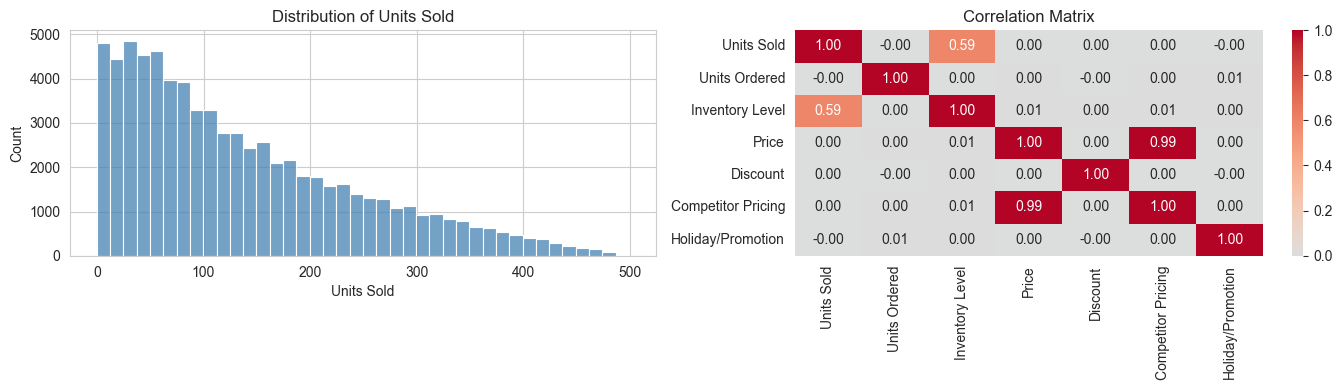

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['Units Sold'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Units Sold')

numeric_cols = [
    'Units Sold',
    'Units Ordered',
    'Inventory Level',
    'Price',
    'Discount',
    'Competitor Pricing',
    'Holiday/Promotion',
]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


## 3. Create next-day target and time-series features

Target mới:

```text
Next_Day_Units_Sold = Units Sold của ngày kế tiếp trong cùng Store ID + Product ID
```

Feature chính:
- `Units Sold`: doanh số ngày hiện tại
- `lag_1`, `lag_7`: doanh số 1 ngày và 7 ngày trước
- `rolling_7_mean`: trung bình doanh số 7 ngày trước, đã shift để tránh leakage
- `Next_DayOfWeek`, `Next_Month`: thông tin lịch của ngày cần dự đoán
- `Store ID`, `Product ID`: định danh chuỗi bán hàng, được one-hot encoding

Không dùng `Category`, `Region`, `Weather Condition`, `Seasonality` vì trong setup next-day forecasting này các biến đó đang nằm ở dòng hiện tại, không chắc là thông tin của ngày cần dự đoán.


In [66]:
model_df = df.copy()

model_df['Next_Date'] = model_df.groupby(GROUP_COLS)['Date'].shift(-1)
model_df[TARGET] = model_df.groupby(GROUP_COLS)['Units Sold'].shift(-1)

model_df['lag_1'] = model_df.groupby(GROUP_COLS)['Units Sold'].shift(1)
model_df['lag_7'] = model_df.groupby(GROUP_COLS)['Units Sold'].shift(7)
model_df['rolling_7_mean'] = (
    model_df.groupby(GROUP_COLS)['Units Sold']
    .transform(lambda s: s.shift(1).rolling(window=7).mean())
)

model_df['Current_DayOfWeek'] = model_df['Date'].dt.dayofweek
model_df['Current_Month'] = model_df['Date'].dt.month
model_df['Next_DayOfWeek'] = model_df['Next_Date'].dt.dayofweek
model_df['Next_Month'] = model_df['Next_Date'].dt.month

feature_cols_with_na = [TARGET, 'Next_Date', 'lag_1', 'lag_7', 'rolling_7_mean']
model_df = model_df.dropna(subset=feature_cols_with_na).reset_index(drop=True)

print('Rows after creating next-day target and lag features:', model_df.shape[0])
model_df[['Date', 'Next_Date', 'Store ID', 'Product ID', 'Units Sold', 'lag_1', 'lag_7', 'rolling_7_mean', TARGET]].head(10)


Rows after creating next-day target and lag features: 72300


,Date,Next_Date,Store ID,Product ID,Units Sold,lag_1,lag_7,rolling_7_mean,Next_Day_Units_Sold
0,2022-01-08,2022-01-09,S001,P0001,2,107.0,127.0,80.285714,350.0
1,2022-01-09,2022-01-10,S001,P0001,350,2.0,81.0,62.428571,36.0
2,2022-01-10,2022-01-11,S001,P0001,36,350.0,5.0,100.857143,16.0
3,2022-01-11,2022-01-12,S001,P0001,16,36.0,58.0,105.285714,104.0
4,2022-01-12,2022-01-13,S001,P0001,104,16.0,147.0,99.285714,80.0
5,2022-01-13,2022-01-14,S001,P0001,80,104.0,37.0,93.142857,177.0
6,2022-01-14,2022-01-15,S001,P0001,177,80.0,107.0,99.285714,176.0
7,2022-01-15,2022-01-16,S001,P0001,176,177.0,2.0,109.285714,97.0
8,2022-01-16,2022-01-17,S001,P0001,97,176.0,350.0,134.142857,69.0
9,2022-01-17,2022-01-18,S001,P0001,69,97.0,36.0,98.000000,123.0


## 4. Prepare X and y

Model đang predict `Next_Day_Units_Sold` dựa trên dữ liệu hiện tại/quá khứ của từng store-product và các biến biết trước như lịch ngày cần dự đoán.


In [67]:
numeric_features = [
    'Units Sold',
    'Units Ordered',
    'Inventory Level',
    'Price',
    'Discount',
    'Competitor Pricing',
    'Holiday/Promotion',
    'lag_1',
    'lag_7',
    'rolling_7_mean',
    'Current_DayOfWeek',
    'Current_Month',
    'Next_DayOfWeek',
    'Next_Month',
]

categorical_features = [
    'Store ID',
    'Product ID',
]

X = pd.get_dummies(
    model_df[numeric_features + categorical_features],
    columns=categorical_features,
    drop_first=True,
    dtype=float,
)
y = model_df[TARGET]

print('Target:', TARGET)
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('X shape:', X.shape)
X.head()


Target: Next_Day_Units_Sold
Numeric features: ['Units Sold', 'Units Ordered', 'Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'lag_1', 'lag_7', 'rolling_7_mean', 'Current_DayOfWeek', 'Current_Month', 'Next_DayOfWeek', 'Next_Month']
Categorical features: ['Store ID', 'Product ID']
X shape: (72300, 37)


,Units Sold,Units Ordered,Inventory Level,Price,Discount,Competitor Pricing,Holiday/Promotion,lag_1,lag_7,rolling_7_mean,...,Product ID_P0011,Product ID_P0012,Product ID_P0013,Product ID_P0014,Product ID_P0015,Product ID_P0016,Product ID_P0017,Product ID_P0018,Product ID_P0019,Product ID_P0020
0,2,119,231,66.30,20,63.82,1,107.0,127.0,80.285714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,350,178,373,41.72,0,38.68,1,2.0,81.0,62.428571,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,36,132,327,32.68,5,34.71,1,350.0,5.0,100.857143,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,16,193,101,27.53,5,27.08,1,36.0,58.0,105.285714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,104,189,145,92.92,0,97.59,0,16.0,147.0,99.285714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Train/validation/test split

Chia theo `Next_Date`, vì đó là ngày mình đang dự đoán:
- **Train 60%**: học model
- **Validation 20%**: kiểm tra trong quá trình làm
- **Test 20%**: đánh giá cuối cùng


In [68]:
unique_target_dates = np.sort(model_df['Next_Date'].unique())
train_cutoff = unique_target_dates[int(len(unique_target_dates) * 0.60)]
val_cutoff = unique_target_dates[int(len(unique_target_dates) * 0.80)]

train_mask = model_df['Next_Date'] < train_cutoff
val_mask = (model_df['Next_Date'] >= train_cutoff) & (model_df['Next_Date'] < val_cutoff)
test_mask = model_df['Next_Date'] >= val_cutoff

X_train = X.loc[train_mask]
X_val = X.loc[val_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_val = y.loc[val_mask]
y_test = y.loc[test_mask]

print(f'Train: {len(X_train):,} rows | target date {model_df.loc[train_mask, "Next_Date"].min().date()} to {model_df.loc[train_mask, "Next_Date"].max().date()}')
print(f'Val  : {len(X_val):,} rows | target date {model_df.loc[val_mask, "Next_Date"].min().date()} to {model_df.loc[val_mask, "Next_Date"].max().date()}')
print(f'Test : {len(X_test):,} rows | target date {model_df.loc[test_mask, "Next_Date"].min().date()} to {model_df.loc[test_mask, "Next_Date"].max().date()}')
print(f'Tỉ lệ: {len(X_train) / len(X):.0%} / {len(X_val) / len(X):.0%} / {len(X_test) / len(X):.0%}')


Train: 43,300 rows | target date 2022-01-09 to 2023-03-17
Val  : 14,500 rows | target date 2023-03-18 to 2023-08-09
Test : 14,500 rows | target date 2023-08-10 to 2024-01-01
Tỉ lệ: 60% / 20% / 20%


## 6. Train Linear Regression


In [69]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = np.clip(model.predict(X_train), 0, None)
y_pred_val = np.clip(model.predict(X_val), 0, None)
y_pred_test = np.clip(model.predict(X_test), 0, None)

print('Intercept:', round(model.intercept_, 2))
print('Number of features:', X_train.shape[1])


Intercept: 137.28
Number of features: 37


## 7. Evaluate model

Metrics được tính trên từng dòng dự đoán:
1. Model predict `Next_Day_Units_Sold` cho từng dòng store-product
2. Tính sai số từng dòng
3. Lấy mean của tất cả sai số đó

Ví dụ: MAE là mean của `abs(actual - predicted)` trên toàn bộ dòng trong tập train/validation/test.


In [70]:
def smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    return np.mean(2 * np.abs(y_pred - y_true) / (denominator + 1e-9)) * 100


def evaluate(y_true, y_pred, label):
    return {
        'Dataset': label,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'sMAPE (%)': smape(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


results = pd.DataFrame([
    evaluate(y_train, y_pred_train, 'Train - Linear Regression'),
    evaluate(y_val, y_pred_val, 'Validation - Linear Regression'),
    evaluate(y_test, y_pred_test, 'Test - Linear Regression'),
])

results.round(3)


,Dataset,MAE,RMSE,sMAPE (%),R2
0,Train - Linear Regression,89.057,108.945,71.936,0.001
1,Validation - Linear Regression,89.704,109.749,72.614,-0.001
2,Test - Linear Regression,88.740,108.229,72.086,-0.001


## 8. Actual vs Predicted


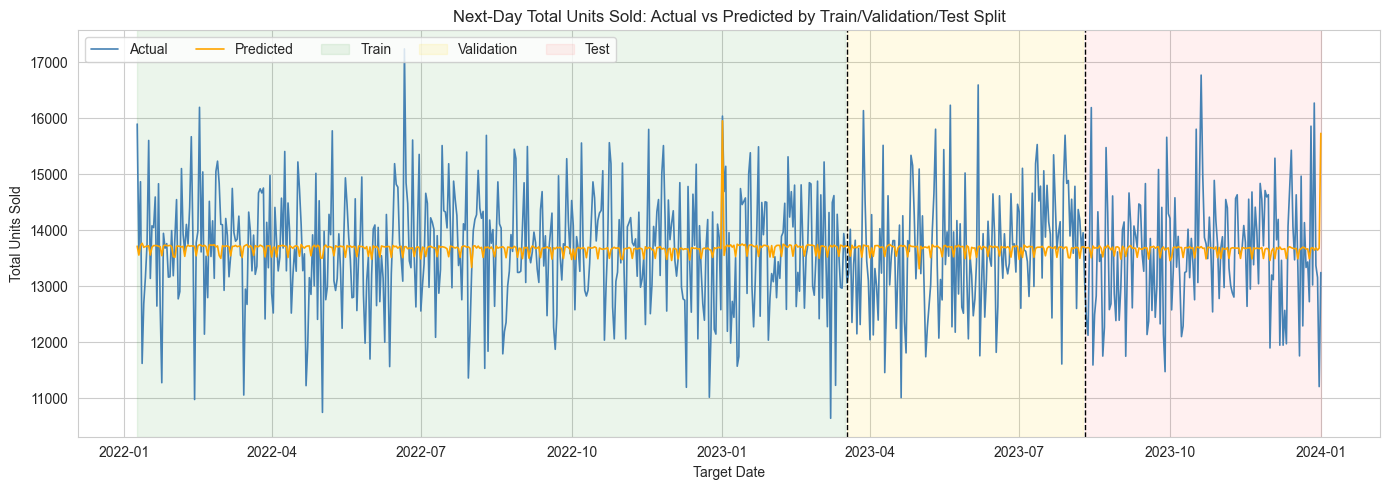

In [71]:
# Daily total actual vs predicted across train/validation/test splits
plot_df = model_df[['Next_Date']].copy()
plot_df['Actual'] = y.values
plot_df['Predicted'] = np.nan
plot_df.loc[train_mask, 'Predicted'] = y_pred_train
plot_df.loc[val_mask, 'Predicted'] = y_pred_val
plot_df.loc[test_mask, 'Predicted'] = y_pred_test

plot_daily = plot_df.groupby('Next_Date')[['Actual', 'Predicted']].sum()

train_start = model_df.loc[train_mask, 'Next_Date'].min()
train_end = model_df.loc[train_mask, 'Next_Date'].max()
val_start = model_df.loc[val_mask, 'Next_Date'].min()
val_end = model_df.loc[val_mask, 'Next_Date'].max()
test_start = model_df.loc[test_mask, 'Next_Date'].min()
test_end = model_df.loc[test_mask, 'Next_Date'].max()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_daily.index, plot_daily['Actual'], label='Actual', color='steelblue', linewidth=1.2)
ax.plot(plot_daily.index, plot_daily['Predicted'], label='Predicted', color='orange', linewidth=1.2)

ax.axvspan(train_start, train_end, color='green', alpha=0.08, label='Train')
ax.axvspan(val_start, val_end, color='gold', alpha=0.10, label='Validation')
ax.axvspan(test_start, test_end, color='red', alpha=0.06, label='Test')
ax.axvline(train_cutoff, color='black', linestyle='--', linewidth=1)
ax.axvline(val_cutoff, color='black', linestyle='--', linewidth=1)

ax.set_title('Next-Day Total Units Sold: Actual vs Predicted by Train/Validation/Test Split')
ax.set_xlabel('Target Date')
ax.set_ylabel('Total Units Sold')
ax.legend(loc='upper left', ncol=5)
plt.tight_layout()
plt.show()


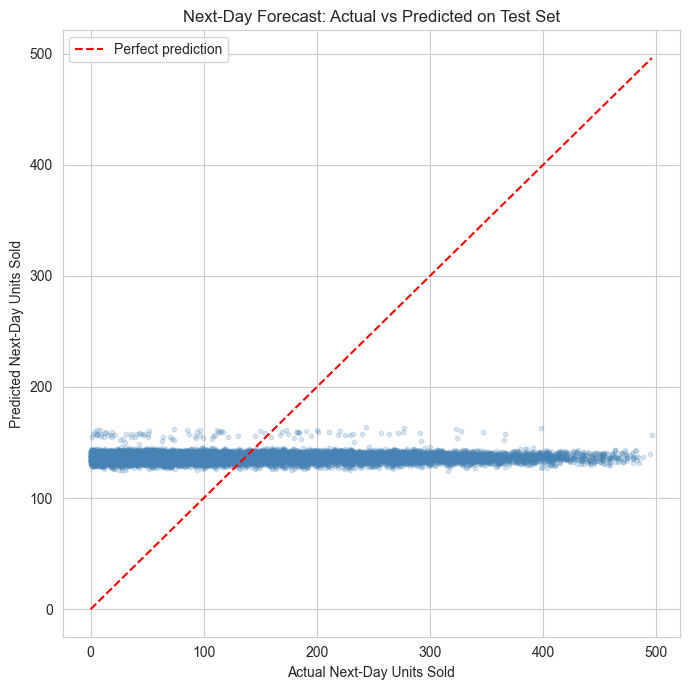

In [72]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.2, s=10, color='steelblue')

limit = max(y_test.max(), y_pred_test.max())
plt.plot([0, limit], [0, limit], 'r--', label='Perfect prediction')

plt.xlabel('Actual Next-Day Units Sold')
plt.ylabel('Predicted Next-Day Units Sold')
plt.title('Next-Day Forecast: Actual vs Predicted on Test Set')
plt.legend()
plt.tight_layout()
plt.show()


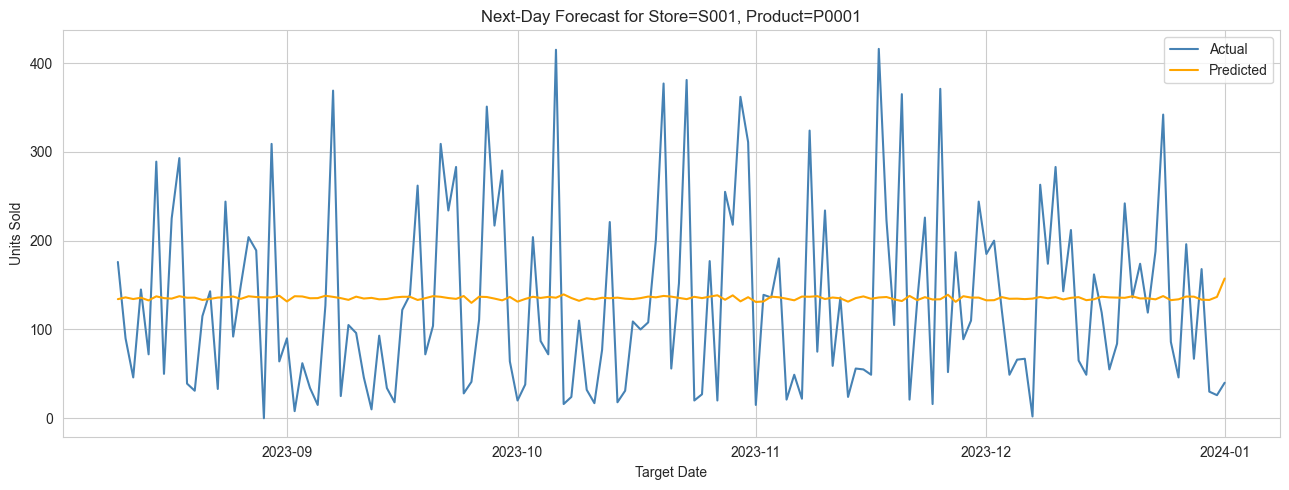

In [73]:
store_id = 'S001'
product_id = 'P0001'

sku_test_mask = (
    test_mask
    & (model_df['Store ID'] == store_id)
    & (model_df['Product ID'] == product_id)
)

sku_plot = model_df.loc[sku_test_mask, ['Next_Date']].copy()
sku_plot['Actual'] = y.loc[sku_test_mask].values
sku_plot['Predicted'] = model.predict(X.loc[sku_test_mask])
sku_plot['Predicted'] = np.clip(sku_plot['Predicted'], 0, None)

plt.figure(figsize=(13, 5))
plt.plot(sku_plot['Next_Date'], sku_plot['Actual'], label='Actual', color='steelblue', linewidth=1.5)
plt.plot(sku_plot['Next_Date'], sku_plot['Predicted'], label='Predicted', color='orange', linewidth=1.5)

plt.title(f'Next-Day Forecast for Store={store_id}, Product={product_id}')
plt.xlabel('Target Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Short conclusion

Notebook này đã được setup lại thành bài toán **next-day time series forecasting** theo từng `Store ID` + `Product ID`.

Nếu model vẫn có R² thấp hoặc metric gần baseline, điều đó nghĩa là Linear Regression và các feature hiện tại vẫn chưa bắt được pattern dự đoán mạnh. Nhưng về mặt setup bài toán, target và split hiện tại đã đúng hướng time series hơn bản record-level regression ban đầu.

Các biến ngoại sinh không chắc biết trước cho ngày dự đoán như `Category`, `Region`, `Weather Condition`, `Seasonality` đã được loại khỏi feature set để tránh dùng nhầm thông tin không phù hợp với forecast horizon.
